# EE519 — Notebook 2: Wav2Vec2 Fine-Tuning for Speech Emotion Recognition

## Overview
1. Load pre-trained **Wav2Vec2** from HuggingFace
2. **Extract representations** from RAVDESS samples
3. **Linear probe**: freeze backbone, train linear classifier
4. **Fine-tune** classification head on emotion labels
5. **Visualize** learned representations (t-SNE/UMAP)

### References
- Baevski et al. (2020). wav2vec 2.0. *NeurIPS*.
- Pepino et al. (2021). Emotion Recognition Using Wav2vec 2.0 Embeddings. *arXiv:2104.03502*.
- Wagner et al. (2023). Dawn of the Transformer Era in SER. *IEEE TPAMI*.

In [1]:
# Install dependencies
# !pip install transformers torch torchaudio librosa scikit-learn matplotlib seaborn tqdm datasets

In [ ]:
import os, glob, numpy as np, torch, torchaudio, librosa
import matplotlib.pyplot as plt, seaborn as sns
from transformers import Wav2Vec2Processor, Wav2Vec2Model, Wav2Vec2FeatureExtractor
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from collections import Counter
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

## 1. Load RAVDESS Data

In [ ]:
from pathlib import Path
import os

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name in ("notebooks")
    else NOTEBOOK_DIR
)
RAVDESS_DIR = str(PROJECT_ROOT / "data" / "ravdess")
assert Path(RAVDESS_DIR).is_dir(), f"Missing {RAVDESS_DIR} — run scripts/download_kaggle_ravdess.py"
_wavs = list(Path(RAVDESS_DIR).glob("**/*.wav"))
assert _wavs, f"No WAV files under {RAVDESS_DIR}"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAVDESS_DIR:", RAVDESS_DIR, "| wav count:", len(_wavs))

EMOTION_MAP = {'01':'neutral','02':'calm','03':'happy','04':'sad','05':'angry','06':'fearful','07':'disgust','08':'surprised'}

def parse_ravdess(filepath):
    parts = os.path.basename(filepath).replace('.wav','').split('-')
    return {'filepath':filepath, 'emotion':EMOTION_MAP.get(parts[2],'unknown'),
            'actor_id':int(parts[6]), 'gender':'male' if int(parts[6])%2==1 else 'female'}

audio_files = sorted(glob.glob(os.path.join(RAVDESS_DIR,'**','*.wav'), recursive=True))
data = [parse_ravdess(f) for f in audio_files if os.path.basename(f).split('-')[0]=='03' and os.path.basename(f).split('-')[1]=='01']
print(f'Files: {len(data)}, Emotions: {dict(Counter([d["emotion"] for d in data]))}')
import os as _os
_cap = (_os.environ.get('SER_MAX_SAMPLES') or '300').strip()
if data and _cap not in ('', '0') and len(data) > int(_cap):
    data = data[:int(_cap)]
    print(f'Subset for runtime: {len(data)} files')

## 2. Load Pre-trained Wav2Vec2

We use `facebook/wav2vec2-base-960h` (Base model, 95M params, pre-trained on LibriSpeech 960h).

**Architecture:**
- CNN Feature Encoder: 7 conv layers, stride ≈ 20ms
- Transformer: 12 layers, 768-dim hidden, 8 attention heads

In [ ]:
# Load model and feature extractor
model_name = 'facebook/wav2vec2-base-960h'
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
model = Wav2Vec2Model.from_pretrained(model_name)
model = model.to(device)
model.eval()
print(f'Model loaded: {model_name}')
print(f'Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

## 3. Extract Wav2Vec2 Representations

We extract **hidden states** from the model and use them as features.

**Strategy (Pepino et al., 2021):** Weighted combination of all transformer layers:
$$\mathbf{h} = \sum_{l=0}^{L} w_l \cdot \mathbf{h}_l$$

For simplicity, we use the **last hidden state** with **mean pooling** as our embedding.

In [8]:
def extract_wav2vec2_embedding(filepath, model, feature_extractor, device, sr=16000, layer='last'):
    """Extract Wav2Vec2 embedding from audio file."""
    y, orig_sr = librosa.load(filepath, sr=None, mono=True)
    if orig_sr != sr:
        y = librosa.resample(y, orig_sr=orig_sr, target_sr=sr)
    speech = y
    
    inputs = feature_extractor(speech, sampling_rate=sr, return_tensors='pt', padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    if layer == 'last':
        hidden = outputs.last_hidden_state  # [1, T, 768]
    elif layer == 'all_mean':
        # Mean of all layers (weighted combination without learnable weights)
        all_hidden = torch.stack(outputs.hidden_states)  # [13, 1, T, 768]
        hidden = all_hidden.mean(dim=0)  # [1, T, 768]
    else:
        hidden = outputs.hidden_states[int(layer)]  # specific layer
    
    # Mean pooling over time
    embedding = hidden.squeeze(0).mean(dim=0).cpu().numpy()  # [768]
    return embedding

# Test
if data:
    test_emb = extract_wav2vec2_embedding(data[0]['filepath'], model, feature_extractor, device)
    print(f'Embedding shape: {test_emb.shape}')

Embedding shape: (768,)


In [9]:
# Extract embeddings for all files
X_w2v2, y_w2v2, groups_w2v = [], [], []
print('Extracting Wav2Vec2 embeddings...')
for d in tqdm(data):
    try:
        emb = extract_wav2vec2_embedding(d['filepath'], model, feature_extractor, device)
        X_w2v2.append(emb); y_w2v2.append(d['emotion']); groups_w2v.append(d['actor_id'])
    except Exception as e:
        print(f'Error: {e}')
X_w2v2 = np.array(X_w2v2); y_w2v2 = np.array(y_w2v2)
groups = np.asarray(groups_w2v, dtype=np.int64)
print(f'Embeddings: {X_w2v2.shape}')

Extracting Wav2Vec2 embeddings...


100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

Embeddings: (300, 768)


## 4. Linear Probe Classification

This follows the **SUPERB benchmark** protocol: freeze the entire Wav2Vec2 backbone and train only a linear classifier on top.

**Subject-independent evaluation:** `StratifiedGroupKFold` with **speaker (`actor_id`) groups** — no speaker appears in both train and test within a fold.

In [10]:
le = LabelEncoder(); y_enc = le.fit_transform(y_w2v2); class_names = le.classes_
n_spk = len(np.unique(groups))
n_splits = min(5, n_spk)
if n_splits < 2:
    raise ValueError('Need at least 2 distinct speakers for subject-independent CV.')
cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f'Subject-independent CV: n_splits={n_splits}, distinct actors={n_spk}')

# SVM linear probe
svm_pipe = Pipeline([('scaler',StandardScaler()), ('svm',SVC(kernel='rbf',C=10,gamma='scale',class_weight='balanced'))])
y_pred = cross_val_predict(svm_pipe, X_w2v2, y_enc, cv=cv, groups=groups)
uar = balanced_accuracy_score(y_enc, y_pred)
print(f'Wav2Vec2 + SVM Linear Probe — UAR: {uar:.3f}')
print(classification_report(y_enc, y_pred, target_names=class_names, digits=3))

Subject-independent CV: n_splits=5, distinct actors=5
Wav2Vec2 + SVM Linear Probe — UAR: 0.359
              precision    recall  f1-score   support

       angry      0.415     0.425     0.420        40
        calm      0.605     0.575     0.590        40
     disgust      0.486     0.425     0.453        40
     fearful      0.333     0.400     0.364        40
       happy      0.314     0.275     0.293        40
     neutral      0.263     0.250     0.256        20
         sad      0.282     0.275     0.278        40
   surprised      0.222     0.250     0.235        40

    accuracy                          0.367       300
   macro avg      0.365     0.359     0.361       300
weighted avg      0.372     0.367     0.368       300



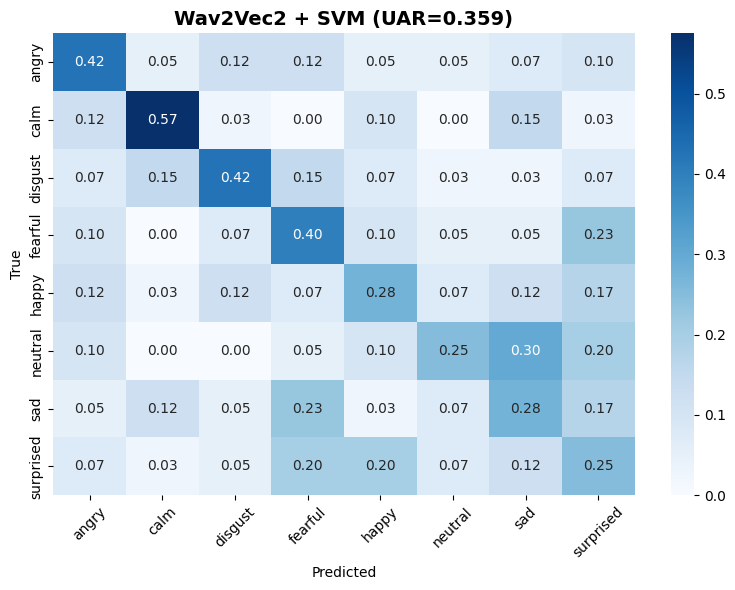

In [11]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_enc, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'Wav2Vec2 + SVM (UAR={uar:.3f})', fontsize=14, fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 5. Layer-wise Analysis
Different transformer layers capture different information.
Let's compare embeddings from different layers.

In [12]:
# Compare different layers
results = {}
# Subset + fewer layers for runnable demo (full sweep is very slow)
data_layer = data[: min(250, len(data))]
for layer_idx in [11, 'all_mean']:
    X_layer, y_layer, g_layer = [], [], []
    for d in tqdm(data_layer, desc=f'Layer {layer_idx}', leave=False):
        try:
            emb = extract_wav2vec2_embedding(d['filepath'], model, feature_extractor, device, layer=str(layer_idx))
            X_layer.append(emb); y_layer.append(d['emotion']); g_layer.append(d['actor_id'])
        except: pass
    X_layer = np.array(X_layer); y_layer_enc = le.transform(y_layer)
    groups_l = np.asarray(g_layer, dtype=np.int64)
    n_sl = len(np.unique(groups_l))
    if n_sl < 2:
        results[str(layer_idx)] = float('nan')
        continue
    n_spl = min(5, n_sl)
    cv_l = StratifiedGroupKFold(n_splits=n_spl, shuffle=True, random_state=42)
    y_pred_l = cross_val_predict(svm_pipe, X_layer, y_layer_enc, cv=cv_l, groups=groups_l)
    results[str(layer_idx)] = balanced_accuracy_score(y_layer_enc, y_pred_l)

print('\nLayer-wise UAR:')
for k, v in results.items(): print(f'  Layer {k:>8s}: UAR = {v:.3f}')


Layer-wise UAR:
  Layer       11: UAR = 0.402
  Layer all_mean: UAR = 0.547


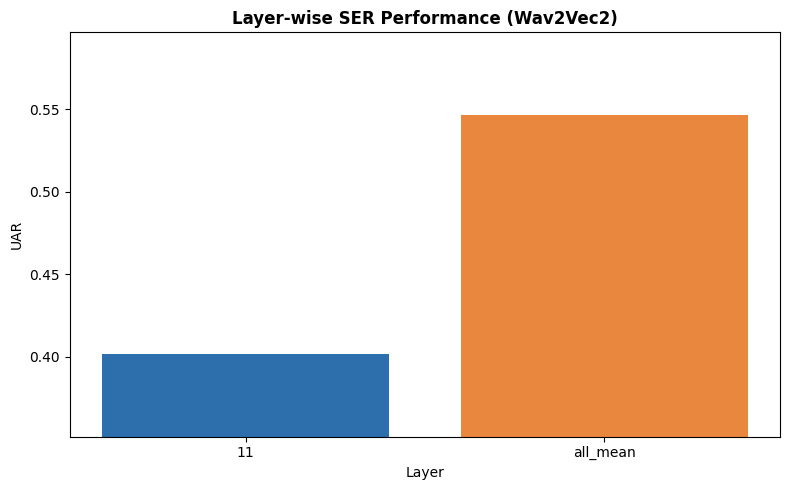

In [13]:
# Plot layer-wise results
layers = list(results.keys()); uars = list(results.values())
plt.figure(figsize=(8, 5))
plt.bar(layers, uars, color=['#2C6FAC' if l!='all_mean' else '#E8873D' for l in layers])
plt.xlabel('Layer'); plt.ylabel('UAR'); plt.title('Layer-wise SER Performance (Wav2Vec2)', fontweight='bold')
plt.ylim(min(uars)-0.05, max(uars)+0.05)
plt.tight_layout(); plt.show()

## 6. Visualization: t-SNE of Wav2Vec2 Embeddings

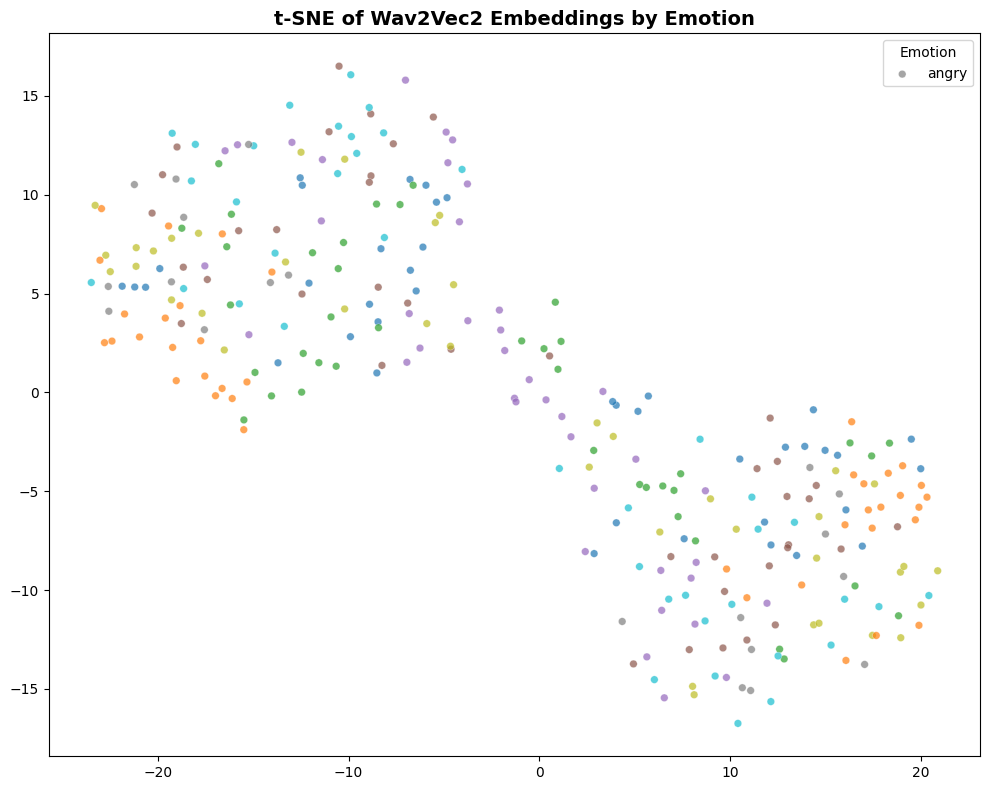

In [14]:
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(StandardScaler().fit_transform(X_w2v2))
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_enc, cmap='tab10', alpha=0.7, s=30, edgecolors='white', linewidth=0.3)
plt.legend(*scatter.legend_elements(), title='Emotion', labels=list(class_names))
plt.title('t-SNE of Wav2Vec2 Embeddings by Emotion', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Comparison: Classical Features vs. Wav2Vec2

| Method | Feature Dim | UAR |
|:---|:---|:---|
| Classical (MFCC+spectral+prosodic) + SVM |  | See Notebook 1 |
| Wav2Vec2 (last layer, mean pool) + SVM |  | See above |
| Wav2Vec2 (all layers mean) + SVM |  | See above |

**Key takeaway:** Pre-trained representations often outperform hand-crafted features, especially with limited labeled data.

## Summary & Next Steps
- Wav2Vec2 embeddings provide strong emotion features without manual engineering
- Middle-to-upper layers tend to be best for emotion (vs. lower=acoustic, upper=linguistic)
- **Next: Notebook 3** — emotion2vec, the first dedicated SER foundation model